In [1]:
!pip install -q dagshub mlflow==2.22.0 lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import mlflow

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 50)

In [3]:
import dagshub
import mlflow

dagshub.init(
    repo_owner='aleko-mamukashvili',
    repo_name='Store-Sales-Forecasting',
    mlflow=True
)

mlflow.set_experiment("LightGBM_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a09c3292-c6f6-40c9-9d4d-0b8947ea829a&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=5bc65f4d93c9b942d270b2fb3fd55bb06679c3843c0a637627a1fdd9af86d2bd




Accessing as ndoda23

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

<Experiment: artifact_location='mlflow-artifacts:/03a42b7449f94cdca4242e697a49f897', creation_time=1783706126365, experiment_id='2', last_update_time=1783706126365, lifecycle_stage='active', name='LightGBM_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [4]:
class LagFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, lag_weeks=(51, 52, 53)):
        self.lag_weeks = lag_weeks

    def fit(self, X, y):
        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = np.asarray(y)
        self.history_ = hist.drop_duplicates(subset=['Store', 'Dept', 'Date'])
        return self

    def transform(self, X):
        X = X.copy()
        for w in self.lag_weeks:
            shifted = self.history_.copy()
            shifted['Date'] = shifted['Date'] + pd.Timedelta(weeks=w)
            shifted = shifted.rename(columns={'Weekly_Sales': f'Sales_Lag_{w}w'})
            X = X.merge(shifted[['Store', 'Dept', 'Date', f'Sales_Lag_{w}w']],
                        on=['Store', 'Dept', 'Date'], how='left')
        return X

In [5]:
class GroupStatsFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept']].copy()
        tmp['Weekly_Sales'] = np.asarray(y)
        self.group_stats_ = (
            tmp.groupby(['Store', 'Dept'])['Weekly_Sales']
               .agg(Group_Mean='mean', Group_Median='median', Group_Std='std')
               .reset_index()
        )
        return self

    def transform(self, X):
        return X.merge(self.group_stats_, on=['Store', 'Dept'], how='left')

In [6]:
class TemporalFeatureBuilder(BaseEstimator, TransformerMixin):
    TYPE_MAP = {'A': 0, 'B': 1, 'C': 2}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X['IsHoliday'] = X['IsHoliday'].astype(int)
        X['Type'] = X['Type'].map(self.TYPE_MAP)
        X = X.drop(columns=['Date'])
        return X

In [7]:
class DropWeakFeatures(BaseEstimator, TransformerMixin):
    WEAK_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.WEAK_COLS if c in X.columns])

In [8]:
class LGBMFinalEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.05, num_boost_round=300, max_depth=-1,
                 objective='mae', random_state=42):
        self.learning_rate = learning_rate
        self.num_boost_round = num_boost_round
        self.max_depth = max_depth
        self.objective = objective
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.feature_cols_ = list(X.columns)
        train_set = lgb.Dataset(X[self.feature_cols_], label=y, weight=sample_weight)
        params = {
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth,
            'objective': self.objective,
            'random_state': self.random_state,
            'deterministic': True,
            'verbosity': -1,
        }
        self.booster_ = lgb.train(params, train_set, num_boost_round=self.num_boost_round)
        return self

    def predict(self, X):
        return self.booster_.predict(X[self.feature_cols_])

In [9]:
MODEL_URI = "models:/LightGBM_WalmartSales/latest"

best_pipeline = mlflow.sklearn.load_model(MODEL_URI)
print("მოდელი ჩაიტვირთა:", MODEL_URI)
print(best_pipeline)

მოდელი ჩაიტვირთა: models:/LightGBM_WalmartSales/latest
Pipeline(steps=[('drop_weak', DropWeakFeatures()),
                ('lags', LagFeatureBuilder()),
                ('group_stats', GroupStatsFeatureBuilder()),
                ('temporal', TemporalFeatureBuilder()),
                ('model',
                 LGBMFinalEstimator(learning_rate=0.1, num_boost_round=150))])


In [11]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q kaggle
!kaggle datasets download -d aslanahmedov/walmart-sales-forecast
!unzip -o walmart-sales-forecast.zip -d data/

Dataset URL: https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast
License(s): copyright-authors
100% 3.36M/3.36M [00:00<00:00, 148MB/s]

Archive:  walmart-sales-forecast.zip
  inflating: data/features.csv       
  inflating: data/stores.csv         
  inflating: data/test.csv           
  inflating: data/train.csv          


In [12]:
DATA_PATH = "data"

test_raw = pd.read_csv(f"{DATA_PATH}/test.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

test_df = test_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
test_df = test_df.merge(stores_raw, on='Store', how='left')

if 'IsHoliday_feat' in test_df.columns:
    test_df = test_df.drop(columns=['IsHoliday_feat'])

test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df = test_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print("Test shape:", test_df.shape)
print("Date range:", test_df['Date'].min().date(), "->", test_df['Date'].max().date())
test_df.head()

Test shape: (115064, 15)
Date range: 2012-11-02 -> 2013-07-26


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [13]:
# sanity check
lag_step = best_pipeline.named_steps['lags']
known_pairs = set(map(tuple, lag_step.history_[['Store', 'Dept']].drop_duplicates().values))
test_pairs = set(map(tuple, test_df[['Store', 'Dept']].drop_duplicates().values))

unseen_pairs = test_pairs - known_pairs
print(f"Test-ში სულ {len(test_pairs)} უნიკალური (Store, Dept) წყვილი.")
print(f"მათგან {len(unseen_pairs)} არასდროს გვინახავს train-ში.")
if unseen_pairs:
    print("მაგალითები:", list(unseen_pairs)[:5])
    print(">>> ამ წყვილებისთვის lag/group features NaN იქნება LightGBM ამას native NaN-handling-ით უმკლავდება, "
          "მაგრამ predictions ამ rows-ისთვის ნაკლებად საიმედოა.")

Test-ში სულ 3169 უნიკალური (Store, Dept) წყვილი.
მათგან 11 არასდროს გვინახავს train-ში.
მაგალითები: [(np.int64(18), np.int64(43)), (np.int64(24), np.int64(43)), (np.int64(36), np.int64(30)), (np.int64(37), np.int64(29)), (np.int64(25), np.int64(99))]
>>> ამ წყვილებისთვის lag/group features NaN იქნება — LightGBM ამას native NaN-handling-ით უმკლავდება, მაგრამ predictions ამ rows-ისთვის ნაკლებად საიმედოა.


In [14]:
predictions = best_pipeline.predict(test_df)

print("Predictions shape:", predictions.shape)
print("Sample:", predictions[:10])

Predictions shape: (115064,)
Sample: [33854.82713664 20978.17432895 19375.41708644 21053.49544733
 24205.68937182 30537.06450867 39419.24758931 43227.34400832
 24799.54713709 17785.03499474]


In [15]:
pred_series = pd.Series(predictions)
print(pred_series.describe())
print()
print("უარყოფითი predictions:", (pred_series < 0).sum(), f"({(pred_series < 0).mean()*100:.2f}%)")
print("NaN predictions:", pred_series.isna().sum())

count    115064.000000
mean      16451.358732
std       22995.535204
min        -782.751262
25%        2081.946206
50%        7742.617543
75%       21013.899190
max      183903.010552
dtype: float64

უარყოფითი predictions: 552 (0.48%)
NaN predictions: 0


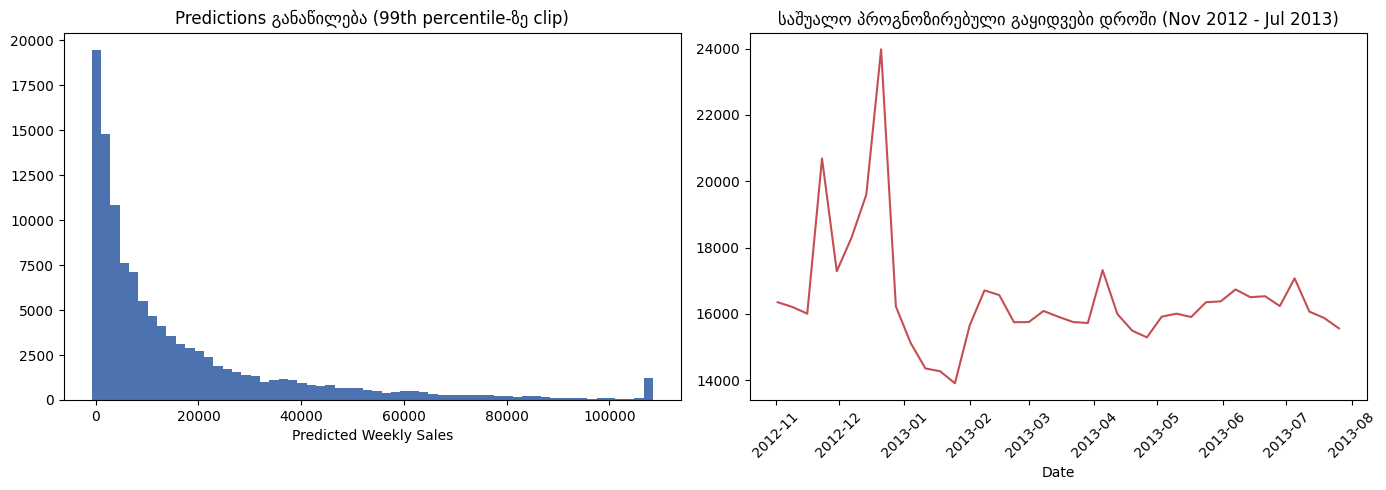

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_series.clip(upper=pred_series.quantile(0.99)), bins=60, color='#4C72B0')
axes[0].set_title('Predictions განაწილება (99th percentile-ზე clip)')
axes[0].set_xlabel('Predicted Weekly Sales')

pred_by_week = pd.DataFrame({'Date': test_df['Date'], 'Pred': predictions}).groupby('Date')['Pred'].mean()
axes[1].plot(pred_by_week.index, pred_by_week.values, color='#C44E52')
axes[1].set_title('საშუალო პროგნოზირებული გაყიდვები დროში (Nov 2012 - Jul 2013)')
axes[1].set_xlabel('Date')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
submission = pd.DataFrame({
    'Id': test_df['Store'].astype(str) + '_' + test_df['Dept'].astype(str) + '_' + test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': predictions
})

negative_count = (submission['Weekly_Sales'] < 0).sum()
submission['Weekly_Sales'] = submission['Weekly_Sales'].clip(lower=0)
print(f"{negative_count} უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.")

print(submission.shape)
submission.head()

552 უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,33854.827137
1,1_1_2012-11-09,20978.174329
2,1_1_2012-11-16,19375.417086
3,1_1_2012-11-23,21053.495447
4,1_1_2012-11-30,24205.689372


In [18]:
submission = pd.DataFrame({
    'Id': test_df['Store'].astype(str) + '_' + test_df['Dept'].astype(str) + '_' + test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': predictions
})

negative_count = (submission['Weekly_Sales'] < 0).sum()
submission['Weekly_Sales'] = submission['Weekly_Sales'].clip(lower=0)
print(f"{negative_count} უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.")

print(submission.shape)
submission.head()

552 უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,33854.827137
1,1_1_2012-11-09,20978.174329
2,1_1_2012-11-16,19375.417086
3,1_1_2012-11-23,21053.495447
4,1_1_2012-11-30,24205.689372


In [19]:
submission.to_csv('lightgbm_walmart_submission.csv', index=False)
print("შენახულია: lightgbm_walmart_submission.csv")
print(submission.shape)

შენახულია: lightgbm_walmart_submission.csv
(115064, 2)


In [21]:
from google.colab import files
files.download('lightgbm_walmart_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>